In [ ]:
!pip install tensorflow opencv-python-headless matplotlib scikit-learn -q

import numpy as np, matplotlib.pyplot as plt, cv2, os, zipfile
from collections import deque
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Conv2D, Conv2DTranspose,
    MaxPooling2D, BatchNormalization, Activation, concatenate, Resizing)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

IMG_H, IMG_W = 80, 160
INPUT_SHAPE  = (80, 160, 3)
BATCH_SIZE, EPOCHS, LR, THRESHOLD, SMOOTH_K = 16, 30, 5e-4, 0.5, 5
ACDC_ROOT  = '/content/acdc_data'
MODEL_PATH = '/content/best_model.h5'

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# CELL 2 : MOUNT DRIVE & EXTRACT ACDC
from google.colab import drive
from IPython.display import Javascript, display

display(Javascript("setInterval(()=>{document.querySelector('colab-toolbar-button#connect')?.click()},60000)"))
drive.mount('/content/drive')
os.makedirs(ACDC_ROOT, exist_ok=True)

IMAGES_ZIP = '/content/drive/MyDrive/rgb_anon_trainvaltest.zip'
MASKS_ZIP  = '/content/drive/MyDrive/gt_trainval.zip'

for label, path in [("Images", IMAGES_ZIP), ("Masks", MASKS_ZIP)]:
    if os.path.exists(path):
        print(f"\nExtracting {label}...")
        with zipfile.ZipFile(path, 'r') as z:
            z.extractall(ACDC_ROOT)
        print(f"{label} done!")
    else:
        print(f"ERROR: {path} not found — check filename above")

print("\nACDC contents:", os.listdir(ACDC_ROOT))

<IPython.core.display.Javascript object>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Extracting Images...
Images done!

Extracting Masks...
Masks done!

ACDC contents: ['rgb_anon', 'gt', 'README.md', 'License.pdf']


In [ ]:
#Cell 3
def load_acdc(root=ACDC_ROOT, n=200):
    imgs, masks = [], []

    for cond in ['fog','night','rain','snow']:
        img_dir  = os.path.join(root,'rgb_anon',cond,'train')
        mask_dir = os.path.join(root,'gt',cond,'train')

        if not os.path.exists(img_dir):
            print(f"{cond}: not found"); continue

        # Build a lookup: frame_id → mask_path
        mask_lookup = {}
        for r,_,fs in os.walk(mask_dir):
            for f in fs:
                if 'labelTrainIds' in f:
                    # Extract frame number from mask filename
                    # e.g. GOPR0376_frame_000843_gt_labelTrainIds.png
                    # frame key = GOPR0376_frame_000843
                    key = f.replace('_gt_labelTrainIds.png','')
                    mask_lookup[key] = os.path.join(r,f)

        print(f"{cond}: {len(mask_lookup)} masks available")

        count = 0
        for r,_,fs in os.walk(img_dir):
            if count >= n: break
            for f in sorted(fs):
                if count >= n: break
                if not f.endswith('_rgb_anon.png'): continue

                # Extract frame key from image filename
                # e.g. GOPR0376_frame_000764_rgb_anon.png
                # frame key = GOPR0376_frame_000764
                key = f.replace('_rgb_anon.png','')

                # Look up matching mask
                if key not in mask_lookup: continue

                img_path  = os.path.join(r,f)
                mask_path = mask_lookup[key]

                img = cv2.imread(img_path)
                msk = cv2.imread(mask_path,
                                 cv2.IMREAD_GRAYSCALE)
                if img is None or msk is None: continue

                img = cv2.resize(
                    cv2.cvtColor(img,cv2.COLOR_BGR2RGB),
                    (IMG_W,IMG_H))
                msk = cv2.resize(msk,(IMG_W,IMG_H),
                    interpolation=cv2.INTER_NEAREST)

                imgs.append(img.astype(np.float32)/255.0)
                masks.append((msk==0).astype(np.float32))
                count += 1

        print(f"{cond}: {count} matched + loaded")

    if not imgs: raise ValueError("No images loaded!")

    X = np.stack(imgs)
    y = np.expand_dims(np.stack(masks),-1)
    X,y = shuffle(X,y,random_state=42)
    s = int(len(X)*0.9)
    print(f"\nTrain:{s} | Val:{len(X)-s}")
    return X[:s],X[s:],y[:s],y[s:]

X_train,X_val,y_train,y_val = load_acdc()

fog: 400 masks available
fog: 200 matched + loaded
night: 400 masks available
night: 200 matched + loaded
rain: 400 masks available
rain: 200 matched + loaded
snow: 400 masks available
snow: 200 matched + loaded

Train:720 | Val:80


In [ ]:
# CELL 4 : BUILD U-NET
def cb(x,f):
    for _ in range(2):
        x=Conv2D(f,3,padding='same',kernel_initializer='he_normal')(x)
        x=BatchNormalization()(x); x=Activation('relu')(x)
    return x

def enc(x,f):
    s=cb(x,f); return MaxPooling2D(2)(s),s

def dec(x,sk,f):
    x=Conv2DTranspose(f,3,strides=2,padding='same')(x)
    x=BatchNormalization()(x); x=Activation('relu')(x)
    x=Resizing(sk.shape[1],sk.shape[2])(x)          # TF2.16+ fix
    return cb(concatenate([x,sk]),f)

def build_unet():
    i=Input(INPUT_SHAPE)
    p1,s1=enc(i,32); p2,s2=enc(p1,64); p3,s3=enc(p2,128); p4,s4=enc(p3,256)
    b=cb(p4,512)
    d=dec(b,s4,256); d=dec(d,s3,128); d=dec(d,s2,64); d=dec(d,s1,32)
    return Model(i,Conv2D(1,1,activation='sigmoid')(d),name='UNet')

model = build_unet()
model.compile(optimizer=Adam(LR),loss='mse',metrics=['accuracy'])
model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80, 160,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 160,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 160,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 80, 160,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 160,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 160,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 80, 160,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 80,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 80,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 80,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 40, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 80,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 80,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 20, 40,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 40,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 40,    │        512 │ conv2d_4[0][0]  

 Total params: 8,644,193 (32.97 MB)

 Trainable params: 8,637,345 (32.95 MB)

 Non-trainable params: 6,848 (26.75 KB)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7624 - loss: 0.1646
Epoch 1: val_loss improved from None to 0.32101, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.8701 - loss: 0.1064 - val_accuracy: 0.5723 - val_loss: 0.3210 - learning_rate: 5.0000e-04
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9414 - loss: 0.0543
Epoch 2: val_loss improved from 0.32101 to 0.14268, saving model to /content/best_model.h5



Epoch 2: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9422 - loss: 0.0518 - val_accuracy: 0.8559 - val_loss: 0.1427 - learning_rate: 5.0000e-04
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9498 - loss: 0.0436
Epoch 3: val_loss improved from 0.14268 to 0.06604, saving model to /content/best_model.h5



Epoch 3: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9515 - loss: 0.0422 - val_accuracy: 0.9311 - val_loss: 0.0660 - learning_rate: 5.0000e-04
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9571 - loss: 0.0368
Epoch 4: val_loss improved from 0.06604 to 0.06148, saving model to /content/best_model.h5



Epoch 4: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.9576 - loss: 0.0362 - val_accuracy: 0.9275 - val_loss: 0.0615 - learning_rate: 5.0000e-04
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9607 - loss: 0.0334
Epoch 5: val_loss did not improve from 0.06148
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9600 - loss: 0.0336 - val_accuracy: 0.9248 - val_loss: 0.0625 - learning_rate: 5.0000e-04
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9626 - loss: 0.0311
Epoch 6: val_loss improved from 0.06148 to 0.04489, saving model to /content/best_model.h5


...


Epoch 11: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9763 - loss: 0.0190 - val_accuracy: 0.9672 - val_loss: 0.0254 - learning_rate: 5.0000e-04
Epoch 12/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9780 - loss: 0.0176
Epoch 12: val_loss did not improve from 0.02535
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.9773 - loss: 0.0180 - val_accuracy: 0.9657 - val_loss: 0.0263 - learning_rate: 5.0000e-04
Epoch 13/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9787 - loss: 0.0169
Epoch 13: val_loss did not improve from 0.02535
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9797 - loss: 0.0162 - val_accuracy: 0.9674 - val_loss: 0.0254 - learning_rate: 5.0000e-04
Epoch 14/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9820 - loss: 0.0143
Epoch 14: val_loss did not improve from 0.02535

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
45/45 ━━━━━━━━━━━━━━━━━━━


Epoch 15: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9833 - loss: 0.0133 - val_accuracy: 0.9704 - val_loss: 0.0225 - learning_rate: 2.5000e-04
Epoch 16/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9852 - loss: 0.0119
Epoch 16: val_loss did not improve from 0.02247
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9853 - loss: 0.0118 - val_accuracy: 0.9694 - val_loss: 0.0234 - learning_rate: 2.5000e-04
Epoch 17/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9861 - loss: 0.0111
Epoch 17: val_loss improved from 0.02247 to 0.02161, saving model to /content/best_model.h5



Epoch 17: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.9861 - loss: 0.0112 - val_accuracy: 0.9719 - val_loss: 0.0216 - learning_rate: 2.5000e-04
Epoch 18/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9859 - loss: 0.0112
Epoch 18: val_loss did not improve from 0.02161
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9861 - loss: 0.0111 - val_accuracy: 0.9683 - val_loss: 0.0244 - learning_rate: 2.5000e-04
Epoch 19/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9873 - loss: 0.0101
Epoch 19: val_loss did not improve from 0.02161
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9874 - loss: 0.0101 - val_accuracy: 0.9702 - val_loss: 0.0226 - learning_rate: 2.5000e-04
Epoch 20/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9886 - loss: 0.0092
Epoch 20: val_loss did not improve from 0.02161

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
45/45 ━━━━━━━━━━━━━━━━━


Epoch 22: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9895 - loss: 0.0085 - val_accuracy: 0.9718 - val_loss: 0.0216 - learning_rate: 1.2500e-04
Epoch 23/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9899 - loss: 0.0082
Epoch 23: val_loss improved from 0.02160 to 0.02112, saving model to /content/best_model.h5



Epoch 23: finished saving model to /content/best_model.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9899 - loss: 0.0082 - val_accuracy: 0.9727 - val_loss: 0.0211 - learning_rate: 1.2500e-04
Epoch 24/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9900 - loss: 0.0081
Epoch 24: val_loss did not improve from 0.02112
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.9900 - loss: 0.0081 - val_accuracy: 0.9720 - val_loss: 0.0217 - learning_rate: 1.2500e-04
Epoch 25/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9907 - loss: 0.0076
Epoch 25: val_loss did not improve from 0.02112
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9907 - loss: 0.0076 - val_accuracy: 0.9710 - val_loss: 0.0224 - learning_rate: 1.2500e-04
Epoch 26/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9910 - loss: 0.0073
Epoch 26: val_loss did not improve from 0.02112

Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
45/45 ━━━━━━━━━━━━━━━━━━━

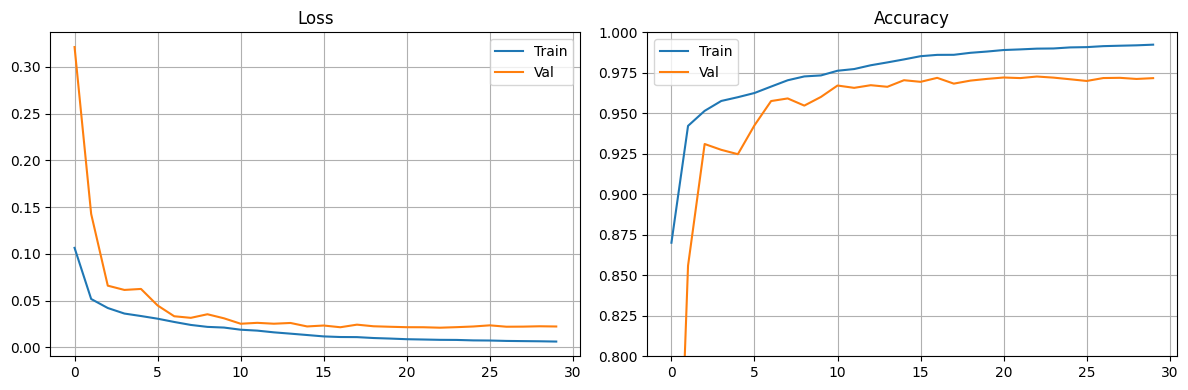

Best val_acc: 97.3%


In [ ]:
# CELL 5 : TRAIN
cbs = [
    ModelCheckpoint(MODEL_PATH,monitor='val_loss',save_best_only=True,verbose=1),
    EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True,verbose=1),
    ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6,verbose=1)
]

history = model.fit(X_train,y_train,validation_data=(X_val,y_val),
                    batch_size=BATCH_SIZE,epochs=EPOCHS,callbacks=cbs,verbose=1)

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
a1.plot(history.history['loss'],label='Train'); a1.plot(history.history['val_loss'],label='Val')
a1.set_title('Loss'); a1.legend(); a1.grid(True)
a2.plot(history.history['accuracy'],label='Train'); a2.plot(history.history['val_accuracy'],label='Val')
a2.set_title('Accuracy'); a2.set_ylim([0.8,1.0]); a2.legend(); a2.grid(True)
plt.tight_layout(); plt.savefig('/content/training.png'); plt.show()
print(f"Best val_acc: {max(history.history['val_accuracy'])*100:.1f}%")

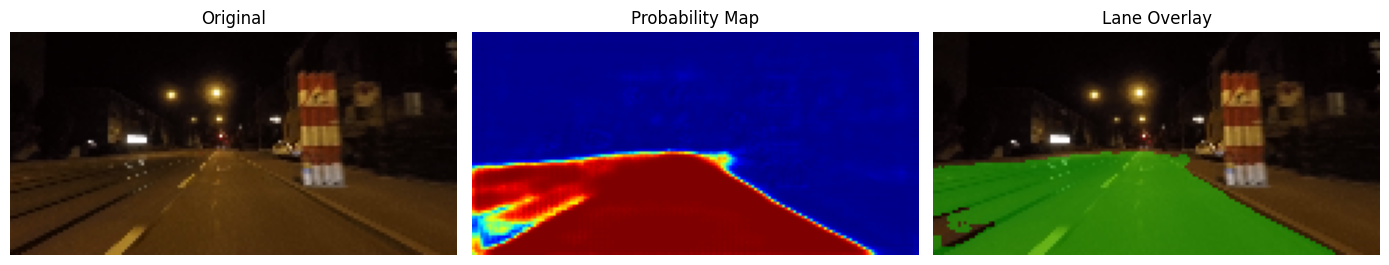

In [ ]:
# CELL 6 : PREDICT ON SINGLE IMAGE
def predict(img_rgb):
    s = cv2.resize(img_rgb,(IMG_W,IMG_H)).astype(np.float32)/255.0
    prob = model.predict(s[np.newaxis],verbose=0)[0,:,:,0]
    mask = cv2.resize((prob>THRESHOLD).astype(np.uint8),
                      (img_rgb.shape[1],img_rgb.shape[0]),
                      interpolation=cv2.INTER_NEAREST)
    out = img_rgb.copy().astype(np.float32)
    px  = mask.astype(bool)
    out[px,0]*=0.6; out[px,1]=out[px,1]*0.6+255*0.4; out[px,2]*=0.6
    out = np.clip(out,0,255).astype(np.uint8)
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    for ax,im,t in zip(axes,[img_rgb,prob,out],
                       ['Original','Probability Map','Lane Overlay']):
        ax.imshow(im,cmap='jet' if t=='Probability Map' else None)
        ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.savefig('/content/prediction.png'); plt.show()

predict((X_val[0]*255).astype(np.uint8))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 80, 160, 3))
  warnings.warn(msg)


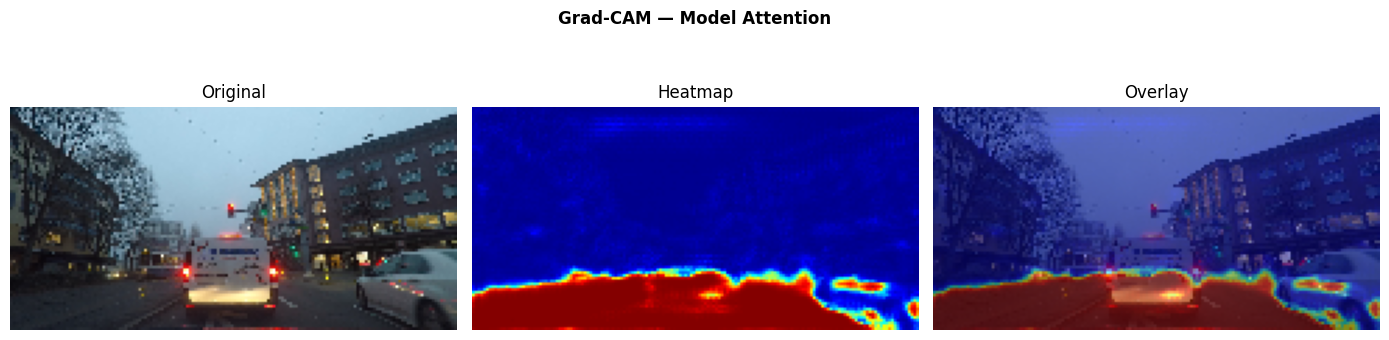

In [ ]:
# CELL 7 : GRAD-CAM
def gradcam(img_rgb):
    s = cv2.resize(img_rgb,(IMG_W,IMG_H)).astype(np.float32)/255.0
    lc = [l for l in model.layers if isinstance(l,Conv2D)][-1].name
    gm = Model(model.inputs,[model.get_layer(lc).output,model.output])
    with tf.GradientTape() as tape:
        co,pred = gm(s[np.newaxis]); tape.watch(co)
        loss = tf.reduce_mean(pred)
    g = tape.gradient(loss,co)
    h = tf.reduce_sum(tf.reduce_mean(g,axis=(0,1,2))*co[0],axis=-1).numpy()
    h = np.maximum(h,0); h = h/h.max() if h.max()>0 else h
    hc = cv2.cvtColor(cv2.applyColorMap(
        cv2.resize((h*255).astype(np.uint8),(IMG_W,IMG_H)),
        cv2.COLORMAP_JET),cv2.COLOR_BGR2RGB)
    ov = np.clip(s*0.5+hc.astype(np.float32)/255*0.5,0,1)
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    fig.suptitle('Grad-CAM — Model Attention',fontweight='bold')
    for ax,im,t in zip(axes,[s,hc,ov],['Original','Heatmap','Overlay']):
        ax.imshow(im); ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.savefig('/content/gradcam.png'); plt.show()

gradcam((X_val[1]*255).astype(np.uint8))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
              precision    recall  f1-score   support

  Background     0.9819    0.9845    0.9832    828756
        Lane     0.9334    0.9228    0.9281    195244

    accuracy                         0.9727   1024000
   macro avg     0.9576    0.9537    0.9556   1024000
weighted avg     0.9726    0.9727    0.9727   1024000

TPR:0.9228 | FPR:0.0155 | IoU:0.8658


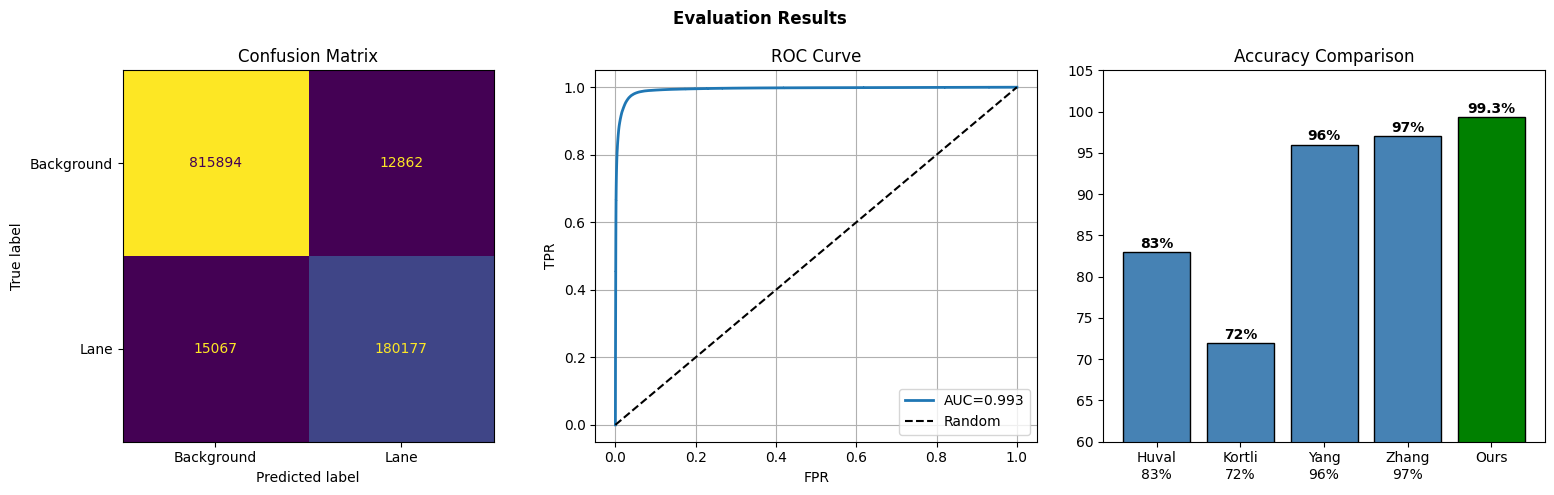

AUC:0.9934 | Saved: samples/training/prediction/gradcam/evaluation.png


In [ ]:
# CELL 8 : EVALUATION
preds  = model.predict(X_val,verbose=1)
y_true = (y_val.flatten()>0.5).astype(int)
y_pred = (preds.flatten()>THRESHOLD).astype(int)
y_prob = preds.flatten()

print(classification_report(y_true,y_pred,
      target_names=['Background','Lane'],digits=4))

tn,fp,fn,tp = confusion_matrix(y_true,y_pred).ravel()
tpr=tp/(tp+fn+1e-7); fpr=fp/(fp+tn+1e-7); iou=tp/(tp+fp+fn+1e-7)
print(f"TPR:{tpr:.4f} | FPR:{fpr:.4f} | IoU:{iou:.4f}")

fig,axes=plt.subplots(1,3,figsize=(16,5))
fig.suptitle('Evaluation Results',fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred),
    display_labels=['Background','Lane']).plot(ax=axes[0],colorbar=False)
axes[0].set_title('Confusion Matrix')

fc,tc,_=roc_curve(y_true,y_prob); ra=auc(fc,tc)
axes[1].plot(fc,tc,linewidth=2,label=f'AUC={ra:.3f}')
axes[1].plot([0,1],[0,1],'k--',label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True)

methods=['Huval\n83%','Kortli\n72%','Yang\n96%','Zhang\n97%','Ours']
scores=[83,72,96,97,round(ra*100,1)]
bars=axes[2].bar(methods,scores,color=['steelblue']*4+['green'],edgecolor='black')
axes[2].set_ylim([60,105]); axes[2].set_title('Accuracy Comparison')
[axes[2].text(b.get_x()+b.get_width()/2,b.get_height()+0.5,
 f'{v}%',ha='center',fontweight='bold') for b,v in zip(bars,scores)]

plt.tight_layout(); plt.savefig('/content/evaluation.png',dpi=120); plt.show()
print(f"AUC:{ra:.4f} | Saved: samples/training/prediction/gradcam/evaluation.png")